In [1]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split, GridSearchCV, cross_val_score
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.svm import SVC
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score
import matplotlib.pyplot as plt
import seaborn as sns
import joblib

In [2]:
import pandas as pd
df=pd.read_csv('df_preprocessed.csv')


In [3]:
print("Number of samples:", df.shape[0])

Number of samples: 20965


In [4]:
print("\nLabel Distribution:")


Label Distribution:


In [5]:
print(df['label_encoded'].value_counts())

label_encoded
2    7660
1    6659
0    6646
Name: count, dtype: int64


In [6]:
print("Available columns:", df.columns.tolist())

Available columns: ['cleaned_text', 'label_encoded', 'word_count', 'text_length', 'avg_word_length', 'punct_count', 'uppercase_ratio']


In [7]:
print("Number of samples:", df.shape[0])
print("\nColumns:", df.columns.tolist())

Number of samples: 20965

Columns: ['cleaned_text', 'label_encoded', 'word_count', 'text_length', 'avg_word_length', 'punct_count', 'uppercase_ratio']


In [8]:
X = df['cleaned_text']
y = df['label_encoded']

print("\nLabel Distribution:")
print(y.value_counts())


Label Distribution:
label_encoded
2    7660
1    6659
0    6646
Name: count, dtype: int64


In [9]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, 
    test_size=0.2, 
    random_state=42, 
    stratify=y
)

In [10]:
print("\nTrain shape:", X_train.shape)
print("Test shape:", X_test.shape)


Train shape: (16772,)
Test shape: (4193,)


In [11]:
tfidf = TfidfVectorizer(
    max_features=5000,
    ngram_range=(1, 2),
    stop_words='english'
)

X_train_tfidf = tfidf.fit_transform(X_train)
X_test_tfidf  = tfidf.transform(X_test)

print("TF-IDF features:", X_train_tfidf.shape[1])

TF-IDF features: 5000


In [12]:
print("\nTraining SVM with Grid Search...")

param_grid = {
    'C': [0.1, 1, 10],
    'kernel': ['linear', 'rbf'],
    'class_weight': ['balanced', None]
}

svm = SVC(random_state=42)

grid_search = GridSearchCV(
    svm, 
    param_grid, 
    cv=5, 
    scoring='f1_macro', 
    n_jobs=-1,
    verbose=1
)

grid_search.fit(X_train_tfidf, y_train)

print("\nBest Parameters:", grid_search.best_params_)

best_svm = grid_search.best_estimator_


Training SVM with Grid Search...
Fitting 5 folds for each of 12 candidates, totalling 60 fits



Best Parameters: {'C': 1, 'class_weight': None, 'kernel': 'rbf'}


In [13]:
# svm_model = SVC(
#     kernel='rbf', 
#     C=1.0, 
#     random_state=42,
#     class_weight='balanced'
# )
# print("\nTraining SVM model")
# svm_model.fit(X_train_tfidf, y_train)

In [17]:
# ====================== Final Evaluation ======================
y_pred = best_model.predict(X_test_tfidf)

print("\n" + "="*65)
print("SVM Final Results")
print("="*65)
print("Accuracy:", round(accuracy_score(y_test, y_pred), 4))

print("\nClassification Report:\n")
print(classification_report(y_test, y_pred, 
                          target_names=['Low', 'Medium', 'High'], 
                          digits=4))



SVM Final Results
Accuracy: 0.8035

Classification Report:

              precision    recall  f1-score   support

         Low     0.8106    0.7728    0.7912      1329
      Medium     0.7877    0.8161    0.8016      1332
        High     0.8118    0.8192    0.8155      1532

    accuracy                         0.8035      4193
   macro avg     0.8033    0.8027    0.8028      4193
weighted avg     0.8037    0.8035    0.8034      4193



In [19]:
# Cross Validation Score
cv_scores = cross_val_score(best_model, X_train_tfidf, y_train, cv=5, scoring='f1_macro')
print("\nCross Validation F1-macro: {:.4f} (+/- {:.4f})".format(cv_scores.mean(), cv_scores.std()*2))


Cross Validation F1-macro: 0.7887 (+/- 0.0145)


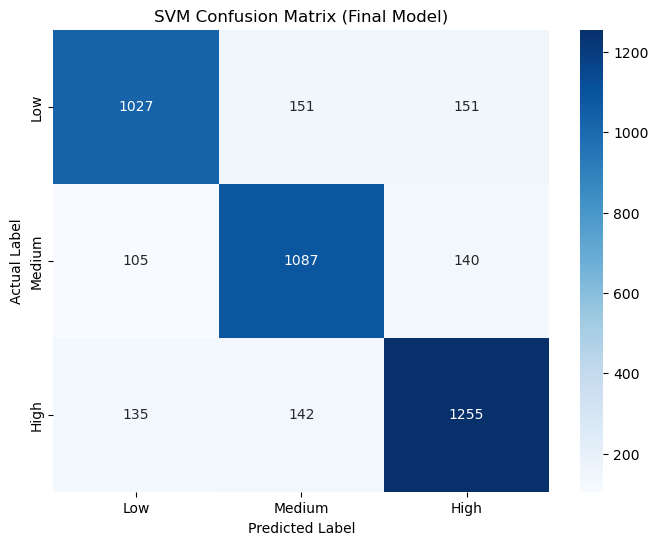

In [20]:
cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(8,6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Low', 'Medium', 'High'],
            yticklabels=['Low', 'Medium', 'High'])
plt.title('SVM Confusion Matrix (Final Model)')
plt.xlabel('Predicted Label')
plt.ylabel('Actual Label')
plt.show()

In [21]:
joblib.dump(best_model, "svm_stress_classifier_final.pkl")
joblib.dump(tfidf, "tfidf_vectorizer.pkl")

print("\n✅ Model and Vectorizer saved successfully!")
print("Files saved: svm_stress_classifier_final.pkl + tfidf_vectorizer.pkl")


✅ Model and Vectorizer saved successfully!
Files saved: svm_stress_classifier_final.pkl + tfidf_vectorizer.pkl


In [22]:
report = classification_report(y_test, y_pred, output_dict=True)
df_report = pd.DataFrame(report).transpose()
df_report.to_csv("svm_results.csv")

print("✅ Detailed Results saved as 'svm_results.csv'")

✅ Detailed Results saved as 'svm_results.csv'
